# Data Preparation and Cleaning

Prepare a clean, standardized dataset ready for augmentation, training, and evaluation.

# Raw Dataset: HAM 10000
- accessed both folders with images from HAM10000 in google drive
- creates folder where processed images will be saved
- read the metadata.csv into a dataframe (ham_meta)

In [ ]:
import os

# Paths
HAM_PATH = "/content/drive/MyDrive/HAM10000"
COMBINED_PATH = os.path.join(HAM_PATH, "prepared_images")

# Create the folder for resized images
os.makedirs(COMBINED_PATH, exist_ok=True)
print("Prepared images folder ready.")

Prepared images folder ready.


In [ ]:
import pandas as pd
META_PATH = os.path.join(HAM_PATH, "HAM10000_metadata.csv")
ham_meta = pd.read_csv(META_PATH)
print("Metadata loaded:", len(ham_meta), "rows")
ham_meta.head()  # preview the first few rows


Metadata loaded: 10015 rows


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


# collect raw image paths
- collects the full paths of all raw .jpg images in both folders --> helps with later looping through during resizing

In [ ]:
# Define paths to the two subfolders containing the raw HAM10000 images
PART1_PATH = os.path.join(HAM_PATH, "HAM10000_images_part_1")
PART2_PATH = os.path.join(HAM_PATH, "HAM10000_images_part_2")
# Initialize an empty list to store full paths to all image files
ham_images = []

# Loop through both image folders to collect all .jpg images
for folder in [PART1_PATH, PART2_PATH]:
    for filename in os.listdir(folder):
        if filename.lower().endswith(".jpg"):
            ham_images.append(os.path.join(folder, filename))

print("Total raw images found:", len(ham_images))


Total raw images found: 10015


#Step 3 — Resize and save images

1. Takes all images from ham_images

2. Converts images to RGB so every image has 3 color channels.

3. Resizes each image to 224×224 pixels (required for CNN input).

4. Keeps filenames consistent by prepending "HAM_" to the original name.

5. Saves the resized images into a single folder called prepared_images/ inside HAM10000.

In [ ]:
from PIL import Image
import tqdm
import os

# Parameters
SIZE = 224  # target width & height
errors = []  # list to store any images that fail

# Loop through all images
for filename in tqdm.tqdm(ham_images):
    try:
        # Open the image and convert to RGB (3 channels)
        img = Image.open(filename).convert("RGB")

        # Resize to 224x224
        img = img.resize((SIZE, SIZE))

        # Save to prepared_images folder with standardized name
        save_name = "HAM_" + os.path.basename(filename)
        img.save(os.path.join(COMBINED_PATH, save_name))
    except:
        errors.append(filename)  # store any files that failed

print("Resizing done.")
print("Total errors:", len(errors))
print("Total prepared images saved:", len(os.listdir(COMBINED_PATH)))


100%|██████████| 10015/10015 [06:37<00:00, 25.22it/s]


Resizing done.
Total errors: 0
Total prepared images saved: 10015


# Checking for eorror or duplicates in prepared_images folder
- ensures every image_id in metadata has a corresponding resized image
- prevents training error caused by missing or duplictaed images
- clean before labelling

In [ ]:
import os
from collections import Counter

COMBINED_PATH = "/content/drive/MyDrive/HAM10000/prepared_images"

all_files = os.listdir(COMBINED_PATH)
file_counts = Counter(all_files)

# Find duplicates
duplicates = [f for f, c in file_counts.items() if c > 1]
if duplicates:
    print("Duplicate files found:", duplicates)
else:
    print("No duplicates detected.")

# Optional: check for missing files (compare with metadata)
import pandas as pd
meta_path = os.path.join("/content/drive/MyDrive/HAM10000", "HAM10000_metadata.csv")
ham_meta = pd.read_csv(meta_path)
expected_files = ["HAM_" + str(x) + ".jpg" for x in ham_meta["image_id"]]
missing_files = [f for f in expected_files if f not in all_files]
if missing_files:
    print("Missing files:", missing_files)
else:
    print("No missing images. All good!")


No duplicates detected.
No missing images. All good!


# Create labels.csv
- new column mapping eacg image_id to the prepared image filename
- filters our any entries where the image is missing
- saves CSV with image_path and label for training
  - provides ground truth labels for the CNN + model only sees images that exist

In [ ]:
# Map each image_id from the metadata to the actual prepared image filename
# - We prefix with "HAM_" to match how images were saved in prepared_images/
# - Example: ISIC_0027419 → HAM_ISIC_0027419.jpg
ham_meta["image_path"] = ham_meta["image_id"].apply(lambda x: f"HAM_{x}.jpg")

# Create a set of all filenames that actually exist in prepared_images/
existing_files_set = set(all_files)

# Filter metadata to include only images that exist
labels_csv = ham_meta[ham_meta["image_path"].isin(existing_files_set)][["image_path", "dx"]].rename(columns={"dx":"label"})

# - This CSV links each image file (image_path) to its ground truth label
# - Used for model training and evaluation
labels_csv_path = os.path.join(HAM_PATH, "labels.csv")
labels_csv.to_csv(labels_csv_path, index=False)

print("Labels CSV created with", len(labels_csv), "entries.")
labels_csv.head()


Labels CSV created with 10015 entries.


,image_path,label
0,HAM_ISIC_0027419.jpg,bkl
1,HAM_ISIC_0025030.jpg,bkl
2,HAM_ISIC_0026769.jpg,bkl
3,HAM_ISIC_0025661.jpg,bkl
4,HAM_ISIC_0031633.jpg,bkl


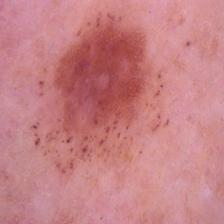

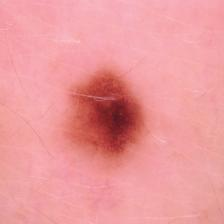

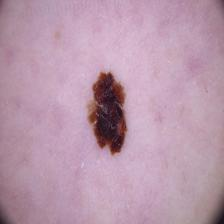

In [ ]:
from IPython.display import Image, display

for img_file in os.listdir(COMBINED_PATH)[:3]:
    display(Image(os.path.join(COMBINED_PATH, img_file)))


# CSV with metadata
- We can use this for data visualization in report and persentation

In [ ]:
# Create a full metadata CSV for EDA or future multimodal models
# - Keeps image_path, label (dx), age, sex, and localization
full_csv = ham_meta[ham_meta["image_path"].isin(existing_files_set)][
    ["image_path", "dx", "age", "sex", "localization"]
].rename(columns={"dx":"label"})

# Save the full metadata CSV
full_csv_path = os.path.join(HAM_PATH, "full_metadata.csv")
full_csv.to_csv(full_csv_path, index=False)

print("Full metadata CSV created with", len(full_csv), "entries.")

# Optional: preview first few rows
full_csv.head()

Full metadata CSV created with 10015 entries.


,image_path,label,age,sex,localization
0,HAM_ISIC_0027419.jpg,bkl,80.0,male,scalp
1,HAM_ISIC_0025030.jpg,bkl,80.0,male,scalp
2,HAM_ISIC_0026769.jpg,bkl,80.0,male,scalp
3,HAM_ISIC_0025661.jpg,bkl,80.0,male,scalp
4,HAM_ISIC_0031633.jpg,bkl,75.0,male,ear
